# Bootstrapping + CI 95% of combined model
- DCA
- Calibration
- boostrapping 

In [1]:
# Training Model OB1+OB2 data
# Import modules
import pandas as pd
from math import sqrt
import os
import random
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, BayesianRidge
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
import sklearn.impute
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import seaborn as sb
import statistics
import seaborn as sn
from sklearn.model_selection import StratifiedKFold
from collections import Counter
import sklearn.ensemble
from statistics import mean
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import KFold, StratifiedKFold, RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
import pandas as pd
import scipy.stats as stats
import os

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

from sklearn.model_selection import GridSearchCV, KFold,RepeatedKFold
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.feature_selection import SelectKBest, f_classif, RFE

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, KFold,RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# from sksurv.linear_model import CoxnetSurvivalAnalysis
# from sksurv.metrics import concordance_index_censored
# from sksurv.util import Surv
#@title Set up the environment
import numpy as np
import sys
import pandas as pd
from collections import Counter, defaultdict
from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense,Flatten,Input,Lambda,GlobalAveragePooling2D,Dropout,Conv2D,BatchNormalization,MaxPooling2D,Input,Activation
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array,array_to_img
from tensorflow.keras.optimizers import Adam,RMSprop,SGD
from tensorflow.keras.applications.densenet import DenseNet169, preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.decomposition import FastICA, PCA
from sklearn.metrics import accuracy_score, f1_score
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import load_model
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import os
import math
from tensorflow.keras.regularizers import l2
import json
import pickle
import random

/Users/sarahgalante/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [50]:
#@title Set up the environment
import numpy as np
import sys
import pandas as pd
from collections import Counter, defaultdict
from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense,Flatten,Input,Lambda,GlobalAveragePooling2D,Dropout,Conv2D,BatchNormalization,MaxPooling2D,Input,Activation
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array,array_to_img
from tensorflow.keras.optimizers import Adam,RMSprop,SGD
from tensorflow.keras.applications.densenet import DenseNet169, preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.decomposition import FastICA, PCA
from sklearn.metrics import accuracy_score, f1_score
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import load_model
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import os
import math
from tensorflow.keras.regularizers import l2
import json
import pickle
import random

## Fixing and loading all available file excels

In [ ]:
val_data=pd.read_csv('')
test_data=pd.read_csv('')
ext_data=pd.read_csv('')



In [52]:
prob_cols_val = [c for c in val_data.columns if 'prob' in c.lower()]

val_data_agg = val_data.groupby('patient_id', as_index=False).agg({
    'label': 'first',
    **{col: 'mean' for col in prob_cols_val}
})

val_data_agg

,patient_id,label,predicted_prob_dl,predicted_prob_hhs,predicted_prob_com
0,O1-A-0003-1m,0,0.721920,0.364866,0.485109
1,O1-A-0003-6m,1,0.422328,0.353320,0.485109
2,O1-A-0010-1m,0,0.531100,0.364866,0.531398
3,O1-A-0010-6m,0,0.492467,0.583925,0.531398
4,O1-A-0028-12m,1,0.779410,0.583925,0.564437
...,...,...,...,...,...
123,O1-A-0392-6m,0,0.887508,0.583925,0.513338
124,O1-A-0395-12m,1,0.965768,0.583925,0.506219
125,O1-A-0395-1m,1,0.886315,0.583925,0.506219
126,O1-A-0398-12m,1,0.361252,0.583925,0.492257


In [53]:
prob_cols_test = [c for c in test_data.columns if 'prob' in c.lower()]

test_data_agg = test_data.groupby('patient_id', as_index=False).agg({
    'label': 'first',
    **{col: 'mean' for col in prob_cols_test}
})

test_data_agg



,patient_id,label,predicted_prob_dl,predicted_prob_hhs,predicted_prob_com
0,O1-A-0012-1m,0,0.320963,0.353320,0.493928
1,O1-A-0012-6m,1,0.755969,0.583925,0.493928
2,O1-A-0017-1m,0,0.940415,0.583925,0.580339
3,O1-A-0017-6m,1,0.973779,0.583925,0.580339
4,O1-A-0018-12m,1,0.330273,0.583925,0.349542
...,...,...,...,...,...
155,O1-A-0390-1m,1,0.465870,0.406293,0.458489
156,O1-A-0399-12m,1,0.988766,0.583925,0.525333
157,O1-A-0399-1m,1,0.978011,0.583925,0.525333
158,O1-A-0400-12m,1,0.820242,0.369046,0.406439


In [54]:
prob_cols_ext = [c for c in ext_data.columns if 'prob' in c.lower()]

ext_data_agg = ext_data.groupby('patient_id', as_index=False).agg({
    'true_label': 'first',
    **{col: 'mean' for col in prob_cols_ext}
})

ext_data_agg

,patient_id,true_label,predicted_prob_dl,predicted_prob_hhs,predicted_prob_com
0,O2-A-001-12m,1,0.003430,0.583925,0.490277
1,O2-A-001-1m,0,0.982926,0.367309,0.490277
2,O2-A-001-3m,0,0.090721,0.583925,0.490277
3,O2-A-002-12m,0,0.523488,0.583925,0.569412
4,O2-A-002-1m,0,0.729012,0.406293,0.569412
...,...,...,...,...,...
476,O2-A-154-1m,0,0.990029,0.406293,0.498645
477,O2-A-155-12m,1,0.919559,0.583925,0.576322
478,O2-A-155-1m,0,0.824474,0.369046,0.576322
479,O2-A-155-3m,0,0.948570,0.583925,0.576322


In [55]:
val_data_agg['mean_prob'] = val_data_agg[
    ['predicted_prob_dl', 'predicted_prob_hhs', 'predicted_prob_com']
].mean(axis=1)

test_data_agg['mean_prob'] = test_data_agg[
    ['predicted_prob_dl', 'predicted_prob_hhs', 'predicted_prob_com']
].mean(axis=1)

ext_data_agg['mean_prob'] = ext_data_agg[
    ['predicted_prob_dl', 'predicted_prob_hhs', 'predicted_prob_com']
].mean(axis=1)

In [57]:
test_data_agg

,patient_id,label,predicted_prob_dl,predicted_prob_hhs,predicted_prob_com,mean_prob
0,O1-A-0012-1m,0,0.320963,0.353320,0.493928,0.389404
1,O1-A-0012-6m,1,0.755969,0.583925,0.493928,0.611274
2,O1-A-0017-1m,0,0.940415,0.583925,0.580339,0.701560
3,O1-A-0017-6m,1,0.973779,0.583925,0.580339,0.712681
4,O1-A-0018-12m,1,0.330273,0.583925,0.349542,0.421247
...,...,...,...,...,...,...
155,O1-A-0390-1m,1,0.465870,0.406293,0.458489,0.443551
156,O1-A-0399-12m,1,0.988766,0.583925,0.525333,0.699341
157,O1-A-0399-1m,1,0.978011,0.583925,0.525333,0.695756
158,O1-A-0400-12m,1,0.820242,0.369046,0.406439,0.531909


In [58]:
test_data_agg['pred_label_mean'] = (test_data_agg['mean_prob'] >= 0.5).astype(int)

y_true_test = test_data_agg['label']
y_prob_test = test_data_agg['mean_prob']
y_pred_test = test_data_agg['pred_label_mean']

tn, fp, fn, tp = confusion_matrix(y_true_test, y_pred_test).ravel()

sensitivity_test = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity_test = tn / (tn + fp) if (tn + fp) > 0 else np.nan
ppv_test = tp / (tp + fp) if (tp + fp) > 0 else np.nan
npv_test = tn / (tn + fn) if (tn + fn) > 0 else np.nan
misclassification_test = (fp + fn) / (tp + tn + fp + fn)

metrics_test = pd.DataFrame({
    'dataset': ['test'],
    'AUC': [roc_auc_score(y_true_test, y_prob_test)],
    'Accuracy': [accuracy_score(y_true_test, y_pred_test)],
    'Balanced_Accuracy': [balanced_accuracy_score(y_true_test, y_pred_test)],
    'F1': [f1_score(y_true_test, y_pred_test)],
    'Sensitivity': [sensitivity_test],
    'Specificity': [specificity_test],
    'PPV': [ppv_test],
    'NPV': [npv_test],
    'Misclassification_Error': [misclassification_test],
    'TP': [tp],
    'TN': [tn],
    'FP': [fp],
    'FN': [fn]
})

print(metrics_test)

  dataset       AUC  Accuracy  Balanced_Accuracy    F1  Sensitivity  \
0    test  0.718902   0.69375           0.690588  0.72     0.741176   

   Specificity  PPV       NPV  Misclassification_Error  TP  TN  FP  FN  
0         0.64  0.7  0.685714                  0.30625  63  48  27  22  


## Calibration curve

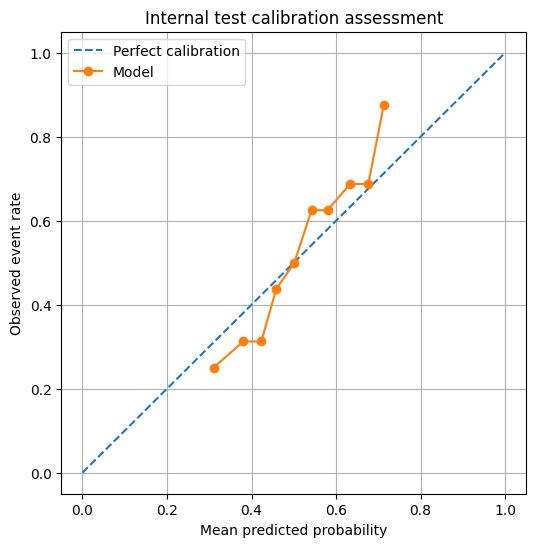

In [59]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# y vero e probabilità predette
true_labels = y_true_test
predicted_probabilities = y_prob_test

# Calcolo curva di calibrazione
prob_true, prob_pred = calibration_curve(
    true_labels,
    predicted_probabilities,
    n_bins=10,
    strategy='quantile'   # oppure 'uniform'
)

# Plot
plt.figure(figsize=(6,6))
plt.plot([0, 1], [0, 1], '--', label='Perfect calibration')
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed event rate')
plt.title('Internal test calibration assessment')
plt.legend()
plt.grid(True)
plt.show()

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# =========================
# DATI
# =========================
y_true = y_true_test
y_prob = y_prob_test

# =========================
# SOGLIE DA TESTARE
# =========================
thresholds = np.arange(0.05, 0.81, 0.05)

N = len(y_true)
prevalence = np.mean(y_true)

results = []

for pt in thresholds:
    # Classe predetta alla soglia pt
    y_pred = (y_prob >= pt).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Net benefit del modello
    net_benefit_model = (tp / N) - (fp / N) * (pt / (1 - pt))

    # Net benefit di "treat all"
    net_benefit_all = prevalence - (1 - prevalence) * (pt / (1 - pt))

    # Net benefit di "treat none"
    net_benefit_none = 0

    results.append({
        'threshold': pt,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn,
        'net_benefit_model': net_benefit_model,
        'net_benefit_all': net_benefit_all,
        'net_benefit_none': net_benefit_none
    })

dca_df = pd.DataFrame(results)

print(dca_df)

    threshold  TP  FP  TN  FN  net_benefit_model  net_benefit_all  \
0        0.05  85  75   0   0           0.506579         0.506579   
1        0.10  85  75   0   0           0.479167         0.479167   
2        0.15  85  75   0   0           0.448529         0.448529   
3        0.20  85  75   0   0           0.414062         0.414062   
4        0.25  85  75   0   0           0.375000         0.375000   
5        0.30  84  71   4   1           0.334821         0.330357   
6        0.35  80  63  12   5           0.287981         0.278846   
7        0.40  76  53  22   9           0.254167         0.218750   
8        0.45  70  38  37  15           0.243182         0.147727   
9        0.50  63  27  48  22           0.225000         0.062500   
10       0.55  48  20  55  37           0.147222        -0.041667   
11       0.60  37  12  63  48           0.118750        -0.171875   
12       0.65  27   7  68  58           0.087500        -0.339286   
13       0.70  11   2  73  74     

In [61]:
dca_df["model_better_than_all_and_none"] = (
    (dca_df["net_benefit_model"] > dca_df["net_benefit_all"]) &
    (dca_df["net_benefit_model"] > dca_df["net_benefit_none"])
)

print(dca_df.loc[dca_df["model_better_than_all_and_none"], ["threshold","net_benefit_model","net_benefit_all","net_benefit_none"]])

    threshold  net_benefit_model  net_benefit_all  net_benefit_none
5        0.30           0.334821         0.330357                 0
6        0.35           0.287981         0.278846                 0
7        0.40           0.254167         0.218750                 0
8        0.45           0.243182         0.147727                 0
9        0.50           0.225000         0.062500                 0
10       0.55           0.147222        -0.041667                 0
11       0.60           0.118750        -0.171875                 0
12       0.65           0.087500        -0.339286                 0
13       0.70           0.039583        -0.562500                 0


## DCA

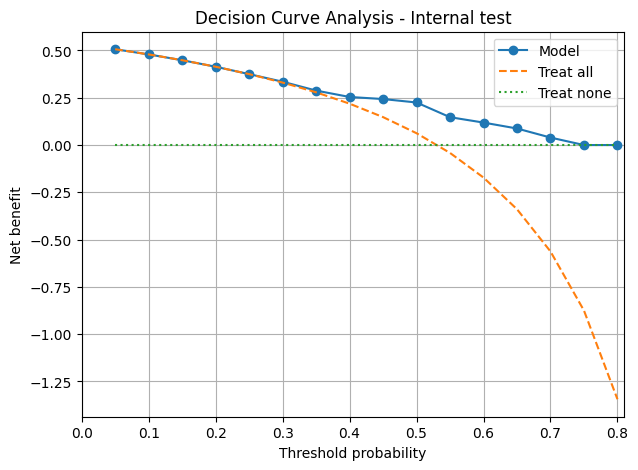

In [62]:
plt.figure(figsize=(7,5))

plt.plot(
    dca_df['threshold'],
    dca_df['net_benefit_model'],
    marker='o',
    label='Model'
)

plt.plot(
    dca_df['threshold'],
    dca_df['net_benefit_all'],
    linestyle='--',
    label='Treat all'
)

plt.plot(
    dca_df['threshold'],
    dca_df['net_benefit_none'],
    linestyle=':',
    label='Treat none'
)

plt.xlabel('Threshold probability')
plt.ylabel('Net benefit')
plt.title('Decision Curve Analysis - Internal test')
plt.xlim(0,0.81)
plt.legend()
plt.grid(True)
plt.show()

In [63]:
ext_data_agg['pred_label_mean'] = (ext_data_agg['mean_prob'] >= 0.5).astype(int)

y_true_ext = ext_data_agg['true_label']
y_prob_ext = ext_data_agg['mean_prob']
y_pred_ext = ext_data_agg['pred_label_mean']

tn, fp, fn, tp = confusion_matrix(y_true_ext, y_pred_ext).ravel()

sensitivity_ext = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity_ext = tn / (tn + fp) if (tn + fp) > 0 else np.nan
ppv_ext = tp / (tp + fp) if (tp + fp) > 0 else np.nan
npv_ext = tn / (tn + fn) if (tn + fn) > 0 else np.nan
misclassification_ext = (fp + fn) / (tp + tn + fp + fn)

metrics_ext = pd.DataFrame({
    'dataset': ['external'],
    'AUC': [roc_auc_score(y_true_ext, y_prob_ext)],
    'Accuracy': [accuracy_score(y_true_ext, y_pred_ext)],
    'Balanced_Accuracy': [balanced_accuracy_score(y_true_ext, y_pred_ext)],
    'F1': [f1_score(y_true_ext, y_pred_ext)],
    'Sensitivity': [sensitivity_ext],
    'Specificity': [specificity_ext],
    'PPV': [ppv_ext],
    'NPV': [npv_ext],
    'Misclassification_Error': [misclassification_ext],
    'TP': [tp],
    'TN': [tn],
    'FP': [fp],
    'FN': [fn]
})

print(metrics_ext)

    dataset       AUC  Accuracy  Balanced_Accuracy        F1  Sensitivity  \
0  external  0.670921  0.600832            0.62483  0.655914     0.851163   

   Specificity       PPV       NPV  Misclassification_Error   TP   TN   FP  FN  
0     0.398496  0.533528  0.768116                 0.399168  183  106  160  32  


## External validation

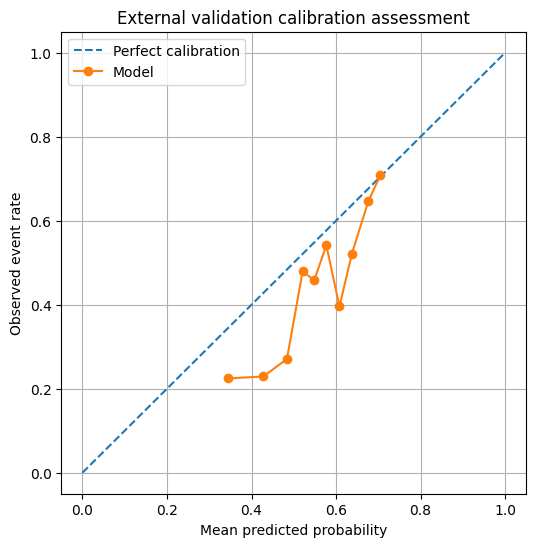

In [64]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# y vero e probabilità predette
true_labels = y_true_ext
predicted_probabilities = y_prob_ext

# Calcolo curva di calibrazione
prob_true, prob_pred = calibration_curve(
    true_labels,
    predicted_probabilities,
    n_bins=10,
    strategy='quantile'   # oppure 'uniform'
)

# Plot
plt.figure(figsize=(6,6))
plt.plot([0, 1], [0, 1], '--', label='Perfect calibration')
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed event rate')
plt.title('External validation calibration assessment')
plt.legend()
plt.grid(True)
plt.show()

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# =========================
# DATI
# =========================
y_true = y_true_ext
y_prob = y_prob_ext

# =========================
# SOGLIE DA TESTARE
# =========================
thresholds = np.arange(0.05, 0.81, 0.05)

N = len(y_true)
prevalence = np.mean(y_true)

results = []

for pt in thresholds:
    # Classe predetta alla soglia pt
    y_pred = (y_prob >= pt).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Net benefit del modello
    net_benefit_model = (tp / N) - (fp / N) * (pt / (1 - pt))

    # Net benefit di "treat all"
    net_benefit_all = prevalence - (1 - prevalence) * (pt / (1 - pt))

    # Net benefit di "treat none"
    net_benefit_none = 0

    results.append({
        'threshold': pt,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn,
        'net_benefit_model': net_benefit_model,
        'net_benefit_all': net_benefit_all,
        'net_benefit_none': net_benefit_none
    })

dca_df = pd.DataFrame(results)

print(dca_df)

    threshold   TP   FP   TN   FN  net_benefit_model  net_benefit_all  \
0        0.05  215  266    0    0           0.417879         0.417879   
1        0.10  215  266    0    0           0.385539         0.385539   
2        0.15  215  266    0    0           0.349395         0.349395   
3        0.20  215  266    0    0           0.308732         0.308732   
4        0.25  215  266    0    0           0.262647         0.262647   
5        0.30  215  257    9    0           0.217998         0.209979   
6        0.35  212  250   16    3           0.160883         0.149208   
7        0.40  203  225   41   12           0.110187         0.078309   
8        0.45  195  195   71   20           0.073710        -0.005481   
9        0.50  183  160  106   32           0.047817        -0.106029   
10       0.55  144  116  150   71           0.004620        -0.228921   
11       0.60  101   77  189  114          -0.030146        -0.382536   
12       0.65   68   33  233  147           0.01395

In [66]:
dca_df["model_better_than_all_and_none"] = (
    (dca_df["net_benefit_model"] > dca_df["net_benefit_all"]) &
    (dca_df["net_benefit_model"] > dca_df["net_benefit_none"])
)

print(dca_df.loc[dca_df["model_better_than_all_and_none"], ["threshold","net_benefit_model","net_benefit_all","net_benefit_none"]])

    threshold  net_benefit_model  net_benefit_all  net_benefit_none
5        0.30           0.217998         0.209979                 0
6        0.35           0.160883         0.149208                 0
7        0.40           0.110187         0.078309                 0
8        0.45           0.073710        -0.005481                 0
9        0.50           0.047817        -0.106029                 0
10       0.55           0.004620        -0.228921                 0
12       0.65           0.013959        -0.580042                 0


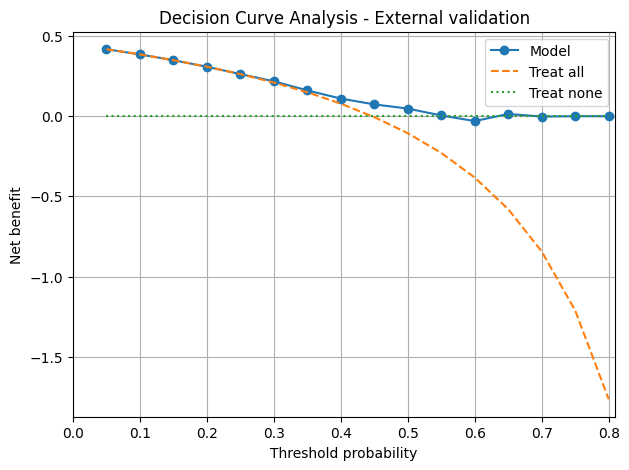

In [67]:
plt.figure(figsize=(7,5))

plt.plot(
    dca_df['threshold'],
    dca_df['net_benefit_model'],
    marker='o',
    label='Model'
)

plt.plot(
    dca_df['threshold'],
    dca_df['net_benefit_all'],
    linestyle='--',
    label='Treat all'
)

plt.plot(
    dca_df['threshold'],
    dca_df['net_benefit_none'],
    linestyle=':',
    label='Treat none'
)

plt.xlabel('Threshold probability')
plt.ylabel('Net benefit')
plt.title('Decision Curve Analysis - External validation')
plt.xlim(0,0.81)
plt.legend()
plt.grid(True)
plt.show()

## BOOTSTRAPPING

## Bootstraapping per checkup

In [91]:
import numpy as np

def generate_row_bootstrap_indices(
    df,
    n_boot=100,
    random_state=42,
    replace=True,
    sample_size=None,
    require_both_classes=False,
    label_col="label",
    max_tries=50000
):
    """
    Row-level bootstrap: campiona righe (check-up) con replacement.

    - sample_size: di default usa len(df) (bootstrap classico)
      puoi anche mettere una frazione (es. int(0.33*len(df))) se vuoi subsampling.
    - require_both_classes: scarta bootstrap degeneri con una sola classe.
    """
    rng = np.random.default_rng(random_state)
    n = len(df)
    if sample_size is None:
        sample_size = n

    idx_all = df.index.to_numpy()

    boot_index_list = []
    tries = 0
    while len(boot_index_list) < n_boot and tries < max_tries:
        tries += 1
        idx = rng.choice(idx_all, size=sample_size, replace=replace)

        if require_both_classes:
            yb = df.loc[idx, label_col].to_numpy()
            if np.unique(yb).size < 2:
                continue

        boot_index_list.append(idx)

    if len(boot_index_list) < n_boot:
        print(f"Only created {len(boot_index_list)} bootstraps (requested {n_boot}).")

    return boot_index_list

### Internal test

In [113]:
prob_col = "mean_prob"  # <-- metti qui il nome reale della colonna con le probabilità

boot_index_list_row = generate_row_bootstrap_indices(
    test_data_agg,
    n_boot=100,
    random_state=42,
    require_both_classes=True,   # consigliato
    label_col="label",
    sample_size=len(test_data_agg)         # bootstrap classico: stessa dimensione del dataset
)


In [114]:
summary_df_row, point_metrics_row, boot_df_row = bootstrap_ci_metrics_cluster(
    test_data_agg,
    prob_col=prob_col,
    boot_index_list=boot_index_list_row,
    label_col="label",
    threshold=0.5,
    ci=0.95,
    estimate_mode="boot_mean"    # <-- MEDIA dei 1000 bootstrap
)

summary_df_row[["Metric", "Reported", "n_boot_used", "Boot_sd"]]

,Metric,Reported,n_boot_used,Boot_sd
0,AUC,0.723 (0.654–0.789),100,0.041832
1,Accuracy,0.693 (0.628–0.772),100,0.038327
2,Balanced_Accuracy,0.691 (0.627–0.768),100,0.038202
3,F1,0.717 (0.647–0.788),100,0.039054
4,Sensitivity,0.738 (0.669–0.816),100,0.044591
5,Specificity,0.643 (0.517–0.752),100,0.058585
6,PPV,0.699 (0.602–0.799),100,0.051881
7,NPV,0.687 (0.581–0.775),100,0.052349
8,Misclassification_Error,0.307 (0.228–0.372),100,0.038327


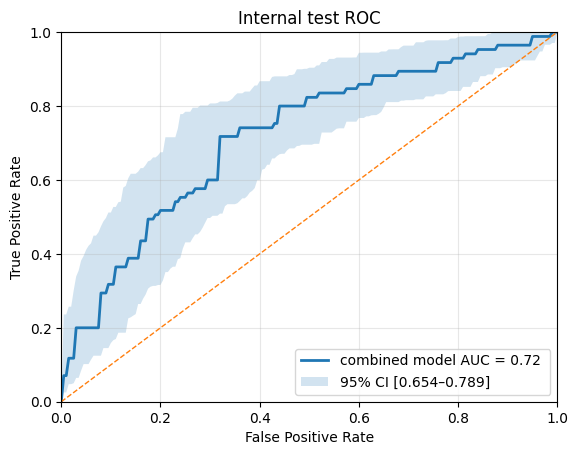

In [116]:
roc_out_row = roc_with_cluster_bootstrap_ci(
    test_data_agg,
    prob_col="mean_prob",
    label_col="label",
    boot_index_list=boot_index_list_row,
    ci=0.95,
    n_grid=201
)
plot_roc_with_ci(roc_out_row, title="Internal test ROC")

In [131]:
prob_col = "predicted_prob_dl"  # <-- metti qui il nome reale della colonna con le probabilità

boot_index_list_row = generate_row_bootstrap_indices(
    test_data_agg,
    n_boot=100,
    random_state=42,
    require_both_classes=True,   # consigliato
    label_col="label",
    sample_size=len(test_data_agg)         # bootstrap classico: stessa dimensione del dataset
)


In [132]:
summary_df_row, point_metrics_row, boot_df_row = bootstrap_ci_metrics_cluster(
    test_data_agg,
    prob_col=prob_col,
    boot_index_list=boot_index_list_row,
    label_col="label",
    threshold=0.5,
    ci=0.95,
    estimate_mode="boot_mean"    # <-- MEDIA dei 1000 bootstrap
)

summary_df_row[["Metric", "Reported", "n_boot_used", "Boot_sd"]]

,Metric,Reported,n_boot_used,Boot_sd
0,AUC,0.715 (0.635–0.783),100,0.040536
1,Accuracy,0.643 (0.575–0.716),100,0.037954
2,Balanced_Accuracy,0.638 (0.573–0.703),100,0.036569
3,F1,0.682 (0.613–0.753),100,0.038880
4,Sensitivity,0.727 (0.645–0.808),100,0.045238
5,Specificity,0.549 (0.439–0.639),100,0.056966
6,PPV,0.644 (0.550–0.729),100,0.049879
7,NPV,0.642 (0.525–0.730),100,0.054416
8,Misclassification_Error,0.357 (0.284–0.425),100,0.037954


In [133]:
prob_col = "predicted_prob_hhs"  # <-- metti qui il nome reale della colonna con le probabilità

summary_df_row, point_metrics_row, boot_df_row = bootstrap_ci_metrics_cluster(
    test_data_agg,
    prob_col=prob_col,
    boot_index_list=boot_index_list_row,
    label_col="label",
    threshold=0.5,
    ci=0.95,
    estimate_mode="boot_mean"    # <-- MEDIA dei 1000 bootstrap
)

summary_df_row[["Metric", "Reported", "n_boot_used", "Boot_sd"]]

,Metric,Reported,n_boot_used,Boot_sd
0,AUC,0.596 (0.501–0.691),100,0.044887
1,Accuracy,0.581 (0.499–0.660),100,0.041408
2,Balanced_Accuracy,0.580 (0.493–0.659),100,0.041116
3,F1,0.605 (0.510–0.682),100,0.045492
4,Sensitivity,0.610 (0.490–0.701),100,0.058541
5,Specificity,0.550 (0.425–0.658),100,0.063440
6,PPV,0.603 (0.494–0.695),100,0.053168
7,NPV,0.557 (0.451–0.667),100,0.057282
8,Misclassification_Error,0.419 (0.340–0.501),100,0.041408


In [134]:
prob_col = "predicted_prob_com"  # <-- metti qui il nome reale della colonna con le probabilità

summary_df_row, point_metrics_row, boot_df_row = bootstrap_ci_metrics_cluster(
    test_data_agg,
    prob_col=prob_col,
    boot_index_list=boot_index_list_row,
    label_col="label",
    threshold=0.5,
    ci=0.95,
    estimate_mode="boot_mean"    # <-- MEDIA dei 1000 bootstrap
)

summary_df_row[["Metric", "Reported", "n_boot_used", "Boot_sd"]]

,Metric,Reported,n_boot_used,Boot_sd
0,AUC,0.629 (0.537–0.704),100,0.041974
1,Accuracy,0.633 (0.575–0.694),100,0.035143
2,Balanced_Accuracy,0.637 (0.575–0.699),100,0.035045
3,F1,0.619 (0.543–0.693),100,0.043503
4,Sensitivity,0.566 (0.471–0.651),100,0.052922
5,Specificity,0.709 (0.600–0.817),100,0.054259
6,PPV,0.686 (0.578–0.783),100,0.053447
7,NPV,0.593 (0.502–0.675),100,0.047729
8,Misclassification_Error,0.367 (0.306–0.425),100,0.035143


### Ext validation

In [136]:
prob_col = "mean_prob"  # <-- metti qui il nome reale della colonna con le probabilità

boot_index_list_row = generate_row_bootstrap_indices(
    ext_data_agg,
    n_boot=100,
    random_state=42,
    require_both_classes=True,   # consigliato
    label_col="true_label",
    sample_size=len(ext_data_agg)         # bootstrap classico: stessa dimensione del dataset
)


In [137]:
summary_df_row, point_metrics_row, boot_df_row = bootstrap_ci_metrics_cluster(
    ext_data_agg,
    prob_col=prob_col,
    boot_index_list=boot_index_list_row,
    label_col="true_label",
    threshold=0.5,
    ci=0.95,
    estimate_mode="boot_mean"    # <-- MEDIA dei 1000 bootstrap
)

summary_df_row[["Metric", "Reported", "n_boot_used", "Boot_sd"]]

,Metric,Reported,n_boot_used,Boot_sd
0,AUC,0.670 (0.615–0.724),100,0.025390
1,Accuracy,0.601 (0.554–0.636),100,0.021346
2,Balanced_Accuracy,0.624 (0.586–0.661),100,0.019358
3,F1,0.656 (0.620–0.696),100,0.021495
4,Sensitivity,0.851 (0.802–0.893),100,0.024700
5,Specificity,0.397 (0.343–0.450),100,0.027708
6,PPV,0.535 (0.489–0.577),100,0.023797
7,NPV,0.766 (0.703–0.835),100,0.036032
8,Misclassification_Error,0.399 (0.364–0.446),100,0.021346


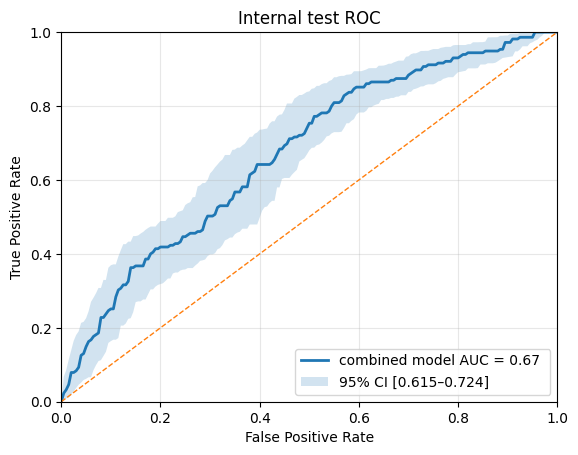

In [140]:
roc_out_row = roc_with_cluster_bootstrap_ci(
    ext_data_agg,
    prob_col="mean_prob",
    label_col="true_label",
    boot_index_list=boot_index_list_row,
    ci=0.95,
    n_grid=201
)
plot_roc_with_ci(roc_out_row, title="Internal test ROC")

In [142]:
prob_col = "predicted_prob_dl"  # <-- metti qui il nome reale della colonna con le probabilità

boot_index_list_row = generate_row_bootstrap_indices(
    ext_data_agg,
    n_boot=100,
    random_state=42,
    require_both_classes=True,   # consigliato
    label_col="true_label",
    sample_size=len(ext_data_agg)         # bootstrap classico: stessa dimensione del dataset
)


In [143]:
summary_df_row, point_metrics_row, boot_df_row = bootstrap_ci_metrics_cluster(
    ext_data_agg,
    prob_col=prob_col,
    boot_index_list=boot_index_list_row,
    label_col="true_label",
    threshold=0.5,
    ci=0.95,
    estimate_mode="boot_mean"    # <-- MEDIA dei 1000 bootstrap
)

summary_df_row[["Metric", "Reported", "n_boot_used", "Boot_sd"]]

,Metric,Reported,n_boot_used,Boot_sd
0,AUC,0.635 (0.581–0.689),100,0.026519
1,Accuracy,0.566 (0.521–0.599),100,0.020818
2,Balanced_Accuracy,0.588 (0.552–0.621),100,0.018847
3,F1,0.624 (0.585–0.659),100,0.021703
4,Sensitivity,0.805 (0.756–0.853),100,0.026538
5,Specificity,0.372 (0.326–0.425),100,0.027828
6,PPV,0.510 (0.459–0.554),100,0.024020
7,NPV,0.701 (0.640–0.771),100,0.036313
8,Misclassification_Error,0.434 (0.401–0.479),100,0.020818


In [145]:
prob_col = "predicted_prob_hhs"  # <-- metti qui il nome reale della colonna con le probabilità

summary_df_row, point_metrics_row, boot_df_row = bootstrap_ci_metrics_cluster(
    ext_data_agg,
    prob_col=prob_col,
    boot_index_list=boot_index_list_row,
    label_col="true_label",
    threshold=0.5,
    ci=0.95,
    estimate_mode="boot_mean"    # <-- MEDIA dei 1000 bootstrap
)

summary_df_row[["Metric", "Reported", "n_boot_used", "Boot_sd"]]

,Metric,Reported,n_boot_used,Boot_sd
0,AUC,0.625 (0.590–0.666),100,0.019595
1,Accuracy,0.584 (0.549–0.631),100,0.021614
2,Balanced_Accuracy,0.609 (0.577–0.647),100,0.019195
3,F1,0.648 (0.607–0.687),100,0.020388
4,Sensitivity,0.855 (0.814–0.896),100,0.022320
5,Specificity,0.363 (0.309–0.441),100,0.033809
6,PPV,0.522 (0.472–0.564),100,0.023706
7,NPV,0.755 (0.679–0.815),100,0.036109
8,Misclassification_Error,0.416 (0.369–0.451),100,0.021614


In [146]:
prob_col = "predicted_prob_com"  # <-- metti qui il nome reale della colonna con le probabilità

summary_df_row, point_metrics_row, boot_df_row = bootstrap_ci_metrics_cluster(
    ext_data_agg,
    prob_col=prob_col,
    boot_index_list=boot_index_list_row,
    label_col="true_label",
    threshold=0.5,
    ci=0.95,
    estimate_mode="boot_mean"    # <-- MEDIA dei 1000 bootstrap
)

summary_df_row[["Metric", "Reported", "n_boot_used", "Boot_sd"]]

,Metric,Reported,n_boot_used,Boot_sd
0,AUC,0.541 (0.493–0.592),100,0.026764
1,Accuracy,0.519 (0.479–0.563),100,0.023837
2,Balanced_Accuracy,0.517 (0.477–0.564),100,0.023796
3,F1,0.484 (0.433–0.538),100,0.027921
4,Sensitivity,0.504 (0.444–0.575),100,0.033835
5,Specificity,0.531 (0.479–0.591),100,0.031274
6,PPV,0.466 (0.410–0.519),100,0.029802
7,NPV,0.568 (0.511–0.639),100,0.031651
8,Misclassification_Error,0.481 (0.437–0.521),100,0.023837


### CM with %

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cm_manual_with_rowperc_bigfonts(
    tn, fp, fn, tp,
    labels=("Non-Failed", "Failed"),
    title=None,
    font_scale=1.6
):
    cm = np.array([[tn, fp],
                   [fn, tp]], dtype=float)

    # Row-wise percentages (each actual class row sums to 100%)
    row_sum = cm.sum(axis=1, keepdims=True)
    perc = np.divide(cm, row_sum, out=np.full_like(cm, np.nan), where=row_sum != 0) * 100.0

    # Font sizes (base * scale)
    base_cell = 14
    base_axis = 12
    base_title = 14
    base_tick = 11

    cell_fs  = int(base_cell * font_scale)
    axis_fs  = int(base_axis * font_scale)
    title_fs = int(base_title * font_scale)
    tick_fs  = int(base_tick * font_scale)

    fig, ax = plt.subplots(figsize=(5.3, 4.7))
    ax.imshow(cm, cmap="Blues")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=tick_fs)
    ax.set_yticklabels(labels, fontsize=tick_fs, rotation=90, va="center")

    ax.set_xlabel("Predicted", fontsize=axis_fs, labelpad=10)
    ax.set_ylabel("Actual", fontsize=axis_fs, labelpad=10)

    if title:
        ax.set_title(title, fontsize=title_fs, pad=12)

    # Numbers in cells: count + (row %)
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0
    for i in range(2):
        for j in range(2):
            v = int(cm[i, j])
            p = perc[i, j]
            txt = f"{v}\n({p:.1f}%)" if np.isfinite(p) else f"{v}\n(n/a)"
            ax.text(
                j, i, txt,
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=cell_fs,
                linespacing=1.15
            )

    # Hide borders
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

    return cm, perc

# ESEMPIO:
# plot_cm_manual_with_rowperc_bigfonts(48, 27, 22, 63, title="My model", font_scale=1.8)

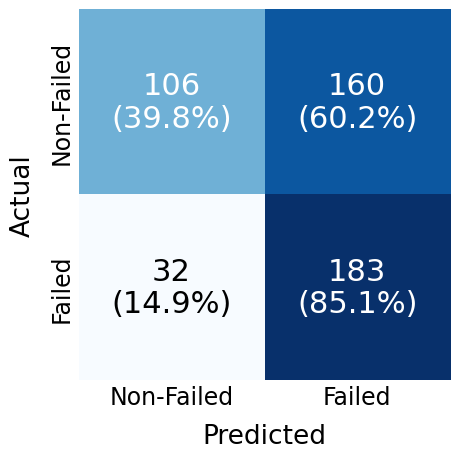

(array([[106., 160.],
        [ 32., 183.]]),
 array([[39.84962406, 60.15037594],
        [14.88372093, 85.11627907]]))

In [8]:
plot_cm_manual_with_rowperc_bigfonts(tn=106, fp=160, fn=32, tp=183)